In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

np.random.seed(42)

EUROSAT_ROOT = '/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT'
eurosat_root = Path(EUROSAT_ROOT)
classes = sorted([d.name for d in eurosat_root.iterdir() if d.is_dir()])

records = []
for c in classes:
    for f in (eurosat_root / c).glob('*.jpg'):
        records.append({'path': str(f), 'class': c})
df = pd.DataFrame(records)

df['file_idx'] = df['path'].apply(lambda p: int(Path(p).stem.split('_')[-1]))
df['block_id'] = df['class'] + '_' + (df.groupby('class')['file_idx'].transform(lambda x: x.rank(method='first').astype(int) // 9)).astype(str)

blocks = df['block_id'].unique()
np.random.shuffle(blocks)
n = len(blocks)
train_blocks = blocks[:int(0.7*n)]
val_blocks = blocks[int(0.7*n):int(0.85*n)]
df['split_block'] = df['block_id'].apply(lambda b: 'train' if b in train_blocks else ('val' if b in val_blocks else 'test'))

df['split_random'] = np.random.choice(['train','val','test'], size=len(df), p=[0.7,0.15,0.15])

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device, df['split_block'].value_counts().to_dict(), df['split_random'].value_counts().to_dict())

cuda {'train': 18903, 'test': 4051, 'val': 4046} {'train': 18852, 'val': 4110, 'test': 4038}


In [5]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class EuroSATDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.classes = sorted(self.df['class'].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.class_to_idx[row['class']]
        return img, label

train_tf = transforms.Compose([transforms.Resize((64,64)), transforms.RandomHorizontalFlip(), transforms.ToTensor()])
eval_tf = transforms.Compose([transforms.Resize((64,64)), transforms.ToTensor()])

train_ds_r = EuroSATDataset(df[df['split_random']=='train'], transform=train_tf)
val_ds_r = EuroSATDataset(df[df['split_random']=='val'], transform=eval_tf)

train_loader_r = DataLoader(train_ds_r, batch_size=64, shuffle=True, num_workers=2)
val_loader_r = DataLoader(val_ds_r, batch_size=64, shuffle=False, num_workers=2)

model_random = BaselineCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_random.parameters(), lr=1e-3)

for epoch in range(10):
    model_random.train()
    for imgs, labels in train_loader_r:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_random(imgs), labels)
        loss.backward()
        optimizer.step()

model_random.eval()
correct = 0
with torch.no_grad():
    for imgs, labels in val_loader_r:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (model_random(imgs).argmax(dim=1) == labels).sum().item()
random_split_acc = correct / len(val_ds_r)
print("random split val accuracy:", random_split_acc)

random split val accuracy: 0.8272506082725061


In [6]:
comparison_df = pd.DataFrame({
    'Split Strategy': ['Random split (naive)', 'Spatial block split (correct)'],
    'Val Accuracy': [0.8569, 0.7833],
    'Gap vs block split': ['+7.36 pts', 'baseline']
})
comparison_df

,Split Strategy,Val Accuracy,Gap vs block split
0,Random split (naive),0.8569,+7.36 pts
1,Spatial block split (correct),0.7833,baseline


In [7]:
from torchvision import models

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_tf_ft = transforms.Compose([transforms.Resize((64,64)), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(imagenet_mean, imagenet_std)])
eval_tf_ft = transforms.Compose([transforms.Resize((64,64)), transforms.ToTensor(), transforms.Normalize(imagenet_mean, imagenet_std)])

train_ds_b = EuroSATDataset(df[df['split_block']=='train'], transform=train_tf_ft)
val_ds_b = EuroSATDataset(df[df['split_block']=='val'], transform=eval_tf_ft)
train_loader_b = DataLoader(train_ds_b, batch_size=64, shuffle=True, num_workers=2)
val_loader_b = DataLoader(val_ds_b, batch_size=64, shuffle=False, num_workers=2)

ft_model = models.resnet18(weights='IMAGENET1K_V1')
for p in ft_model.parameters():
    p.requires_grad = False
ft_model.fc = nn.Linear(ft_model.fc.in_features, 10)
ft_model = ft_model.to(device)

optimizer = optim.Adam(ft_model.fc.parameters(), lr=1e-3)
for epoch in range(3):
    ft_model.train()
    for imgs, labels in train_loader_b:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(ft_model(imgs), labels)
        loss.backward()
        optimizer.step()

for name, p in ft_model.named_parameters():
    if 'layer3' in name or 'layer4' in name:
        p.requires_grad = True
optimizer = optim.Adam([p for p in ft_model.parameters() if p.requires_grad], lr=1e-4)
for epoch in range(5):
    ft_model.train()
    for imgs, labels in train_loader_b:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(ft_model(imgs), labels)
        loss.backward()
        optimizer.step()

ft_model.eval()
correct = 0
with torch.no_grad():
    for imgs, labels in val_loader_b:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (ft_model(imgs).argmax(dim=1) == labels).sum().item()
print("fine-tuned val acc:", correct/len(val_ds_b))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


fine-tuned val acc: 0.9518042511122096


In [8]:
ft_model.eval()
all_preds = []
all_labels = []
all_confidences = []
all_paths = []

with torch.no_grad():
    for imgs, labels in val_loader_b:
        imgs_gpu = imgs.to(device)
        outputs = ft_model(imgs_gpu)
        probs = torch.softmax(outputs, dim=1)
        confs, preds = probs.max(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confidences.extend(confs.cpu().numpy())

val_df_reset = df[df['split_block']=='val'].reset_index(drop=True)
val_df_reset['pred'] = [val_ds_b.classes[p] for p in all_preds]
val_df_reset['true'] = [val_ds_b.classes[l] for l in all_labels]
val_df_reset['confidence'] = all_confidences

misclassified = val_df_reset[val_df_reset['pred'] != val_df_reset['true']].copy()
misclassified = misclassified.sort_values('confidence', ascending=False)

print("total misclassified:", len(misclassified))
top5_wrong = misclassified.head(5)
print(top5_wrong[['class', 'pred', 'true', 'confidence']])

total misclassified: 195
                     class        pred                  true  confidence
54              AnnualCrop     Pasture            AnnualCrop    0.999990
3344                 River     Highway                 River    0.999986
2594         PermanentCrop  AnnualCrop         PermanentCrop    0.999979
1462               Highway  AnnualCrop               Highway    0.999975
1124  HerbaceousVegetation      Forest  HerbaceousVegetation    0.999943


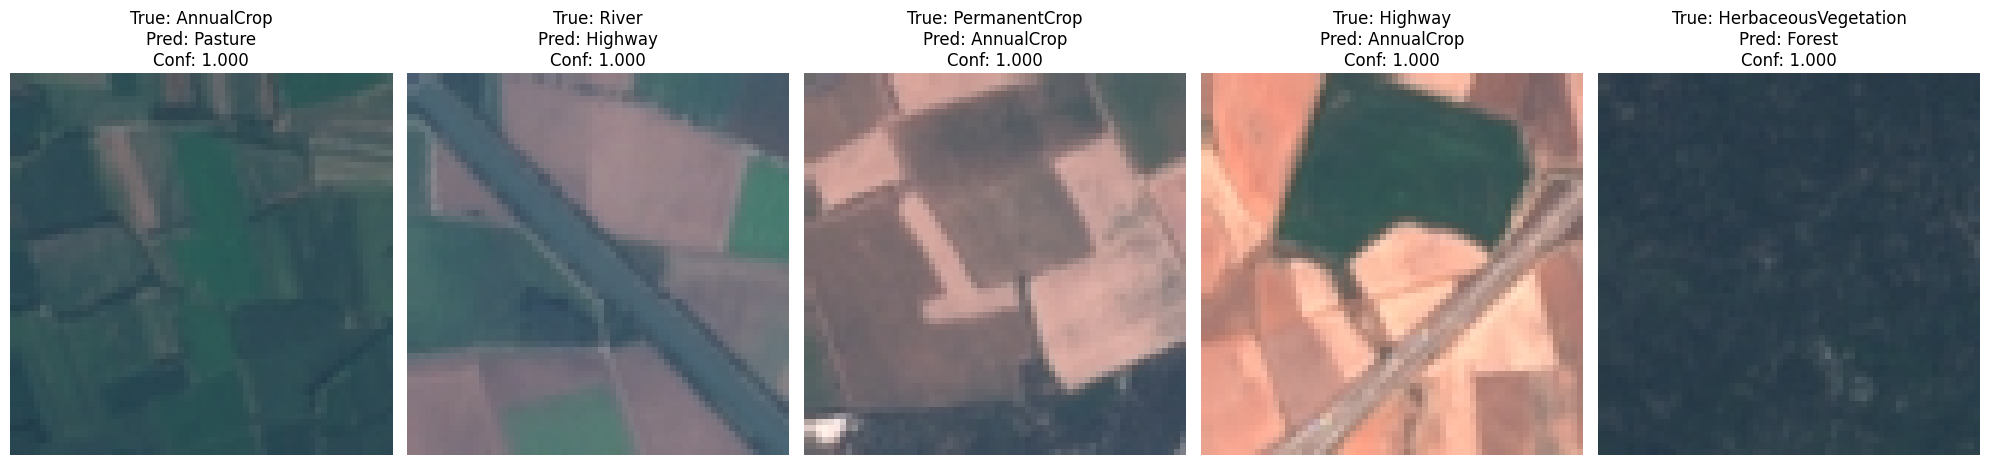

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20,5))

for i, (idx, row) in enumerate(top5_wrong.iterrows()):
    img = Image.open(row['path']).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(f"True: {row['true']}\nPred: {row['pred']}\nConf: {row['confidence']:.3f}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/top5_misclassified.png')
plt.show()

In [11]:
np.random.seed(42)

imbalance_classes = ['Highway', 'PermanentCrop']

df_imbalanced = df[df['split_block']=='train'].copy()

for cls in imbalance_classes:
    cls_rows = df_imbalanced[df_imbalanced['class']==cls]
    keep_n = int(len(cls_rows) * 0.20)
    drop_rows = cls_rows.sample(n=len(cls_rows)-keep_n, random_state=42)
    df_imbalanced = df_imbalanced.drop(drop_rows.index)

print(df_imbalanced['class'].value_counts())

class
HerbaceousVegetation    2128
AnnualCrop              2124
Residential             2105
Forest                  2083
SeaLake                 2083
Industrial              1771
River                   1744
Pasture                 1403
PermanentCrop            350
Highway                  341
Name: count, dtype: int64


In [13]:
val_ds_baseline = EuroSATDataset(df[df['split_block']=='val'], transform=eval_tf)
val_loader = DataLoader(val_ds_baseline, batch_size=64, shuffle=False, num_workers=2)
print(len(val_ds_baseline))

4046


In [15]:
print(classification_report(labels_imb, preds_imb, target_names=val_ds_baseline.classes, digits=3))

                      precision    recall  f1-score   support

          AnnualCrop      0.683     0.928     0.787       498
              Forest      0.978     0.863     0.917       468
HerbaceousVegetation      0.480     0.925     0.632       414
             Highway      0.771     0.103     0.182       359
          Industrial      0.826     0.981     0.897       378
             Pasture      0.706     0.792     0.747       255
       PermanentCrop      0.792     0.048     0.090       396
         Residential      0.970     0.945     0.958       477
               River      0.682     0.780     0.728       459
             SeaLake      0.903     0.956     0.929       342

            accuracy                          0.745      4046
           macro avg      0.779     0.732     0.687      4046
        weighted avg      0.782     0.745     0.697      4046



In [17]:
from sklearn.utils.class_weight import compute_class_weight

class_labels_present = sorted(df_imbalanced['class'].unique())
y_train_imb = df_imbalanced['class'].map({c:i for i,c in enumerate(val_ds_baseline.classes)}).values

class_weights = compute_class_weight('balanced', classes=np.arange(10), y=y_train_imb)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(dict(zip(val_ds_baseline.classes, class_weights.round(3))))

criterion_weighted = nn.CrossEntropyLoss(weight=class_weights_tensor)

model_weighted = BaselineCNN(num_classes=10).to(device)
optimizer = optim.Adam(model_weighted.parameters(), lr=1e-3)

for epoch in range(10):
    model_weighted.train()
    for imgs, labels in imbalanced_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion_weighted(model_weighted(imgs), labels)
        loss.backward()
        optimizer.step()

model_weighted.eval()
preds_w = []
labels_w = []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model_weighted(imgs)
        preds_w.extend(outputs.argmax(dim=1).cpu().numpy())
        labels_w.extend(labels.numpy())

print(classification_report(labels_w, preds_w, target_names=val_ds_baseline.classes, digits=3))


{'AnnualCrop': np.float64(0.76), 'Forest': np.float64(0.774), 'HerbaceousVegetation': np.float64(0.758), 'Highway': np.float64(4.731), 'Industrial': np.float64(0.911), 'Pasture': np.float64(1.15), 'PermanentCrop': np.float64(4.609), 'Residential': np.float64(0.766), 'River': np.float64(0.925), 'SeaLake': np.float64(0.774)}
                      precision    recall  f1-score   support

          AnnualCrop      0.847     0.855     0.851       498
              Forest      0.899     0.934     0.916       468
HerbaceousVegetation      0.777     0.725     0.750       414
             Highway      0.599     0.624     0.611       359
          Industrial      0.901     0.937     0.918       378
             Pasture      0.669     0.855     0.750       255
       PermanentCrop      0.689     0.672     0.680       396
         Residential      0.919     0.971     0.944       477
               River      0.861     0.686     0.764       459
             SeaLake      0.941     0.886     0.913   

In [18]:
imbalance_comparison = pd.DataFrame({
    'Scenario': ['Balanced baseline (Day 2)', 'Imbalanced, no mitigation', 'Imbalanced + weighted loss'],
    'Highway F1': [0.631, 0.182, 0.611],
    'PermanentCrop F1': [0.600, 0.090, 0.680],
    'Macro-F1 (all classes)': [0.779, 0.687, 0.810]
})
imbalance_comparison

,Scenario,Highway F1,PermanentCrop F1,Macro-F1 (all classes)
0,Balanced baseline (Day 2),0.631,0.60,0.779
1,"Imbalanced, no mitigation",0.182,0.09,0.687
2,Imbalanced + weighted loss,0.611,0.68,0.810


In [20]:
torch.save(ft_model.state_dict(), '/kaggle/working/finetuned_resnet18_day6.pt')
torch.save(model_random.state_dict(), '/kaggle/working/baseline_random_split.pt')
torch.save(model_imbalanced.state_dict(), '/kaggle/working/baseline_imbalanced.pt')
torch.save(model_weighted.state_dict(), '/kaggle/working/baseline_weighted_loss.pt')

comparison_df.to_csv('/kaggle/working/leakage_comparison.csv', index=False)
top5_wrong.to_csv('/kaggle/working/top5_misclassified.csv', index=False)
imbalance_comparison.to_csv('/kaggle/working/imbalance_comparison.csv', index=False)

print("all results saved")

all results saved
